In [1]:
# ==========================================
# 1. PREPARACIÓ DE L'ENTORN MODERN
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


In [2]:
#Librerías necesarias
using ITensors
using ITensorMPS
using Plots
using LinearAlgebra

Esta función construye la representación exacta en formato QTT de una campana gaussiana aproximada mediante su desarrollo en serie de Taylor de grado χ−1. El algoritmo se estructura en cuatro bloques fundamentales que separan la física del problema de la geometría de la red:

    1. Vector de Coeficientes: Calcula los pesos analíticos de la serie de Maclaurin para la función e−αx2, asignando valores nulos a las potencias impares y guardando el resultado en un vector frontera.

    2. Nodo Inicial (Sitio 1): Inicializa el tensor de la red inyectando las potencias base del bit menos significativo (20).

    3. Generador Universal (Bulk): Constituye el núcleo geométrico del algoritmo. Para los sitios intermedios, utiliza la matriz de transferencia de Pascal (basada en el teorema del binomio) para propagar y acumular de forma exacta la mezcla algebraica de todas las potencias espaciales de los bits iterados.

    4. Nodo Final (Sitio N): Actúa como el cierre del circuito. Calcula la última contribución binomial y la contrae inmediatamente con el vector de coeficientes de Taylor, colapsando la dimensión virtual y materializando la función objetivo en el MPS.

In [3]:
function generar_gaussiana_qtt_pascal(sites, x_min,dx, N, alpha, chi)
    b = MPS(sites)
    blinks = [Index(chi, "link,l=$i") for i in 1:(N-1)]
    
    # 1. Generamos los coeficientes analíticos de Taylor para e^(-αx²)
    # Coeficientes: C_m = (-α)^n / n! para potencias pares m = 2n, y 0 para impares.
    C = zeros(Float64, chi)
    for j in 1:chi
        p = j - 1  # Grado de la potencia (0 a chi-1)
        if p % 2 == 0
            n = div(p, 2)
            C[j] = (-alpha)^n / factorial(n)
        else
            C[j] = 0.0
        end
    end

    # --- NODO 1: Inicialización de Potencias locales ---
    b[1] = ITensor(sites[1], blinks[1])
    for s in 1:2
        c = (s == 1) ? 0.0 : dx * 2.0^0
        for j in 1:chi
            # Inyecta c^(j-1). Nota: 0.0^0 en Julia es 1.0 de forma segura
            b[1][sites[1]=>s, blinks[1]=>j] = (x_min+c)^(j-1)
        end
    end

    # --- BULK: Sitios 2 a N-1 (Matriz de Transferencia de Pascal) ---
    # Aplica de forma exacta: (x + c)^m = Σ Binomial(m, k) * c^(m-k) * x^k
    for k in 2:(N-1)
        b[k] = ITensor(blinks[k-1], sites[k], blinks[k])
        val_bit = dx * 2.0^(k-1)
        
        for s in 1:2
            c = (s == 1) ? 0.0 : val_bit
            for i in 1:chi
                for j in i:chi
                    # i representa la potencia previa, j la potencia futura
                    b[k][blinks[k-1]=>i, sites[k]=>s, blinks[k]=>j] = binomial(j-1, i-1) * c^(j-i)
                end
            end
        end
    end

    # --- NODO N: Cierre del Circuito y Proyección de Coeficientes ---
    # Recibe las potencias acumuladas hasta N-1, calcula la última transición y colapsa con C
    b[N] = ITensor(blinks[N-1], sites[N])
    val_bit = dx * 2.0^(N-1)
    
    for s in 1:2
        c = (s == 1) ? 0.0 : val_bit
        for i in 1:chi
            val_sum = 0.0
            for j in i:chi
                val_sum += C[j] * binomial(j-1, i-1) * c^(j-i)
            end
            b[N][blinks[N-1]=>i, sites[N]=>s] = val_sum
        end
    end
    
    return b
end

generar_gaussiana_qtt_pascal (generic function with 1 method)

In [4]:
# --- PARÁMETROS DE LA MALLA ULTRA-DENSA ---
N = 20                  # 20 qubits/bits
dim_total = 1 << N      # 2^20 = 1.048.576 puntos
x_min = -1
x_max = 1  
dx = (x_max - x_min) / dim_total  

alpha_g = 3.5
sites = siteinds("Qubit", N)

println("=== EXPERIMENTO QTT DE ALTA ESCALA ===")
println("Puntos en la malla: ", dim_total)
println("Número de Qubits:   ", N)
println("-"^50)

# Definimos chi para convergencia hasta x=1
chi=33
# Ejecutamos la construcción (Toma milisegundos)
println("Generando MPS comprimido directamente...")
@time mps_gaussiana = generar_gaussiana_qtt_pascal(sites, x_min,dx, N, alpha_g,chi)

# ==========================================================
# COMPRESIÓN NUMÉRICA DEL RESULTADO
# ==========================================================
# Le pasamos un truncamiento numérico al MPS final para ver si el 
# algoritmo puede reordenar y optimizar la base todavía más.
println("-"^50)
println("Max Bond Dim del QTT generado:   ", maxlinkdim(mps_gaussiana))
mps_optimizado = truncate!(mps_gaussiana; cutoff=1e-15)
println("Max Bond Dim tras optimización:  ", maxlinkdim(mps_optimizado))

# Calculamos el número de parámetros reales en memoria RAM
num_parametros_qtt = 0
for tensor in mps_optimizado
    num_parametros_qtt += dim(tensor)  # 'dim' extrae el tamaño del espacio del tensor
end

println("\n=== COMPARATIVA DE MEMORIA REAL ===")
println("Elementos Vector Clásico:     ", dim_total, " (Floats)")
println("Elementos Guardados en QTT:   ", num_parametros_qtt, " (Floats)")
println("Factor de compresión real:    ", round(dim_total / num_parametros_qtt, digits=1), "x menos RAM")

println("\n=== CONTROL DE CALIDAD 1: MUESTREO DE PUNTOS ===")

# Función modificada y segura para extraer el valor de un MPS en un índice clásico
function evaluar_mps_en_punto(mps, sites, indice_clasico)
    # Copiamos el MPS para no alterar el original durante la proyección
    mps_temp = copy(mps)
    
    for j in 1:length(mps_temp)
        # Determinamos si el bit j está en 0 (estado 1) o 1 (estado 2)
        bit_val = ((indice_clasico >> (j - 1)) & 1) + 1
        
        # Creamos un proyector local puro tipo vector (1 en la posición del bit, 0 en la otra)
        proyector = ITensor(sites[j])
        proyector[sites[j] => bit_val] = 1.0
        
        # Contraemos el nodo local del MPS con el proyector para colapsar ese qubit
        mps_temp[j] = mps_temp[j] * proyector
    end
    
    # Al final, contraemos todos los enlaces virtuales remanentes para obtener el número escalar
    resultado = mps_temp[1]
    for j in 2:length(mps_temp)
        resultado *= mps_temp[j]
    end
    
    return scalar(resultado)
end

# Puntos a evaluar: Origen (i=0), Centro (i=dim_total/2), Final (i=dim_total-1)
indices_prueba = [0, div(dim_total, 4), div(dim_total, 2), 3*div(dim_total, 4),dim_total - 1]

for idx in indices_prueba
    # Reconstruimos la coordenada x real correspondiente a ese índice
    x = x_min
    for j in 1:N
        bit = (idx >> (j - 1)) & 1
        x += bit * dx * 2.0^(j - 1)
    end
    
    val_analitico = exp(-alpha_g * x^2)
    val_qtt = evaluar_mps_en_punto(mps_optimizado, sites, idx)
    
    println("En x = ", round(x, digits=4), " -> Real: ", val_analitico, " | QTT: ", val_qtt)
end

=== EXPERIMENTO QTT DE ALTA ESCALA ===
Puntos en la malla: 1048576
Número de Qubits:   20
--------------------------------------------------
Generando MPS comprimido directamente...
  0.911598 seconds (1.80 M allocations: 162.133 MiB, 4.03% gc time, 97.58% compilation time)
--------------------------------------------------
Max Bond Dim del QTT generado:   33
Max Bond Dim tras optimización:  7

=== COMPARATIVA DE MEMORIA REAL ===
Elementos Vector Clásico:     1048576 (Floats)
Elementos Guardados en QTT:   742 (Floats)
Factor de compresión real:    1413.2x menos RAM

=== CONTROL DE CALIDAD 1: MUESTREO DE PUNTOS ===
En x = -1.0 -> Real: 0.0301973834223185 | QTT: 0.030201488470940056
En x = -0.5 -> Real: 0.4168620196785084 | QTT: 0.41686194935296145
En x = 0.0 -> Real: 1.0 | QTT: 0.9999999242684279
En x = 0.5 -> Real: 0.4168620196785084 | QTT: 0.41686199531115153
En x = 1.0 -> Real: 0.03019778660319141 | QTT: 0.030205992373209947


=== EVALUANDO 32 PUNTOS PARA LA GRÁFICA ===
Evaluación completada. Error máximo en la gráfica: 8.205770018535757e-6


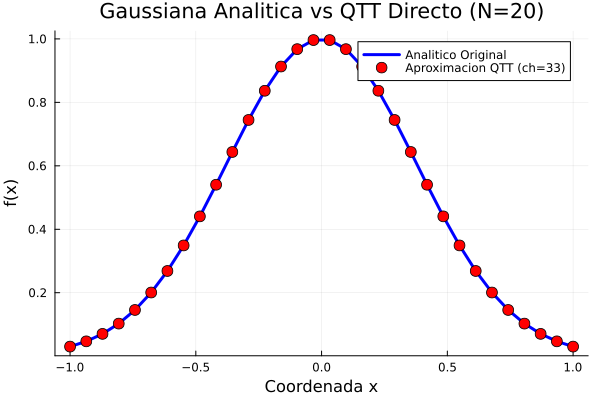

In [5]:
# --- CONFIGURACIÓN DEL MUESTREO PARA LA GRÁFICA ---
n_puntos_grafica = 32
# Generamos índices distribuidos uniformemente desde 0 hasta (dim_total - 1)
indices_grafica = [round(Int, i * (dim_total - 1) / (n_puntos_grafica - 1)) for i in 0:(n_puntos_grafica - 1)]

# Listas para almacenar los datos
x_vals = Float64[]
y_analitico = Float64[]
y_qtt = Float64[]

println("=== EVALUANDO $n_puntos_grafica PUNTOS PARA LA GRÁFICA ===")
for idx in indices_grafica
    # 1. Reconstruir la coordenada x real para este índice
    x = x_min
    for j in 1:N
        bit = (idx >> (j - 1)) & 1
        x += bit * dx * 2.0^(j - 1)
    end
    push!(x_vals, x)
    
    # 2. Calcular valor analítico real
    push!(y_analitico, exp(-alpha_g * x^2))
    
    # 3. Extraer valor del QTT optimizado
    push!(y_qtt, evaluar_mps_en_punto(mps_optimizado, sites, idx))
end

# --- GENERACIÓN DE LA GRÁFICA ---
# Creamos el objeto del gráfico de la curva analítica
p = plot(x_vals, y_analitico, 
     label="Analitico Original", 
     linewidth=3, 
     linecolor=:blue, 
     title="Gaussiana Analitica vs QTT Directo (N=20)",
     xlabel="Coordenada x", 
     ylabel="f(x)",
     legend=:topright)

# Superponemos los puntos extraídos del QTT en el mismo objeto 'p'
scatter!(p, x_vals, y_qtt, 
         label="Aproximacion QTT (ch=$chi)", 
         markersize=6, 
         markercolor=:red, 
         markershape=:circle)

# Imprimimos primero el error
error_max = maximum(abs.(y_analitico .- y_qtt))
println("Evaluación completada. Error máximo en la gráfica: ", error_max)

# Mostramos la gráfica
display(p)

Esta función construye la representación exacta en formato QTT de la función de Bessel de primera especie y orden cero, J0​(x), aproximada mediante su desarrollo en serie de Taylor truncado hasta el grado χ−1. Al igual que en el caso de la gaussiana, el algoritmo separa la geometría de la red de la física del problema, con una adaptación crucial en el cálculo aritmético:

    1. Vector de Coeficientes Estabilizado: Calcula los pesos de la serie alternada de J0(x). Para evitar el desbordamiento numérico (overflow) provocado por los factoriales al elevar la dimensión χ, el cálculo se realiza en el espacio logarítmico utilizando la función logΓ(z) (lgamma). Esto garantiza la estabilidad numérica incluso para polinomios de grado muy alto.

    2. Nodo Inicial (Sitio 1): Inicia la propagación de la red inyectando las potencias espaciales correspondientes al bit menos significativo de la malla discreta.

    3. Generador Universal (Bulk): Reutiliza la matriz de transferencia geométrica basada en el teorema del binomio de Pascal. Actúa como una autopista universal que propaga y acumula todas las potencias espaciales de forma exacta a lo largo de los enlaces virtuales intermedios.

    4. Nodo Final (Sitio N): Actúa como el cierre del circuito tensorial. Calcula la contribución del último bit y la contrae directamente con el vector de coeficientes de Bessel calculado en el primer paso, colapsando la suma y grabando la oscilación de la función en el MPS.

In [6]:
function generar_bessel_J0_qtt(sites, x_min,dx, N, chi)
    b = MPS(sites)
    blinks = [Index(chi, "link,l=$i") for i in 1:(N-1)]
    
    # 1. COEFICIENTES ANALÍTICOS DE TAYLOR PARA J_0(x)
    # C_p = (-1)^m / ( (m!)^2 * 2^(2m) ) para potencias pares p = 2m
    C = zeros(Float64, chi)
    for j in 1:chi
        p = j - 1  # Grado de la potencia (0 a chi-1)
        if p % 2 == 0
            m = div(p, 2)
            
            # En lugar de (m!)^2 * 2^(2m), calculamos su logaritmo:
            # log( (m!)^2 * 2^(2m) ) = 2 * log(m!) + 2m * log(2)
            log_denominador = 2.0 * lgamma(m + 1) + (2m) * log(2.0)
            
            # Coeficiente final: (-1)^m * exp(-log_denominador)
            signo = (m % 2 == 0) ? 1.0 : -1.0
            C[j] = signo * exp(-log_denominador)
        else
            C[j] = 0.0
        end
    end

    # --- NODO 1: Inicialización de Potencias ---
    b[1] = ITensor(sites[1], blinks[1])
    for s in 1:2
        c = (s == 1) ? 0.0 : dx * 2.0^0
        for j in 1:chi
            b[1][sites[1]=>s, blinks[1]=>j] = (x_min+c)^(j-1)
        end
    end

    # --- BULK UNIVERSAL: Matriz de Pascal ---
    for k in 2:(N-1)
        b[k] = ITensor(blinks[k-1], sites[k], blinks[k])
        val_bit = dx * 2.0^(k-1)
        for s in 1:2
            c = (s == 1) ? 0.0 : val_bit
            for i in 1:chi
                for j in i:chi
                    b[k][blinks[k-1]=>i, sites[k]=>s, blinks[k]=>j] = binomial(j-1, i-1) * c^(j-i)
                end
            end
        end
    end

    # --- NODO N: Cierre con Coeficientes de Bessel ---
    b[N] = ITensor(blinks[N-1], sites[N])
    val_bit = dx * 2.0^(N-1)
    for s in 1:2
        c = (s == 1) ? 0.0 : val_bit
        for i in 1:chi
            val_sum = 0.0
            for j in i:chi
                val_sum += C[j] * binomial(j-1, i-1) * c^(j-i)
            end
            b[N][blinks[N-1]=>i, sites[N]=>s] = val_sum
        end
    end
    
    return b
end

generar_bessel_J0_qtt (generic function with 1 method)

=== GENERANDO BESSEL J_0(x) EN QTT ===
  0.210748 seconds (649.77 k allocations: 144.882 MiB, 10.84% gc time, 69.46% compilation time)

=== COMPRIMIENDO RED DE TENSORES ===
  0.006559 seconds (14.48 k allocations: 10.865 MiB)
--------------------------------------------------
Max Bond Dim optimizado por SVD: 8
--------------------------------------------------

Extrayendo puntos del espacio comprimido para graficar...


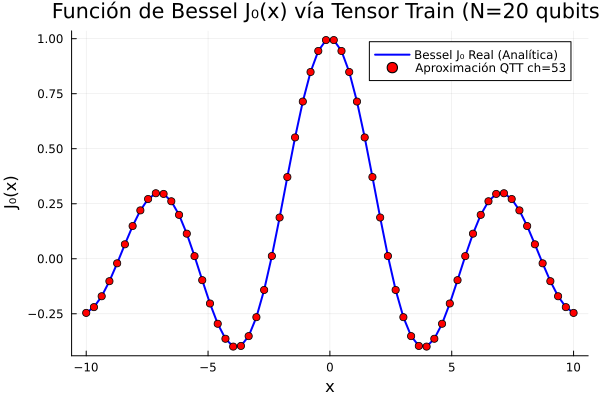

In [7]:
using Plots
using SpecialFunctions # Para comparar con la función clásica besselj0(x)

# --- Configuración de la Malla Cuántica ---
N_qubits = 20
N_puntos_malla = 2^N_qubits  # 1,048,576 puntos
x_min=-10
x_max = 10                 # Intervalo [0, 10] para ver oscilaciones
dx = (x_max-x_min) / (N_puntos_malla - 1)

# Crear los índices locales del QTT (2 estados por qubit: bit 0 y bit 1)
sites = siteinds("Qubit", N_qubits)

# Definimos chi para convergencia hasta x=10
chi_bessel = 53

println("=== GENERANDO BESSEL J_0(x) EN QTT ===")
@time mps_bessel = generar_bessel_J0_qtt(sites, x_min,dx, N_qubits, chi_bessel)

# Compresión SVD inteligente para descubrir el rango real óptimo
println("\n=== COMPRIMIENDO RED DE TENSORES ===")
@time mps_bessel_opt = truncate!(mps_bessel; cutoff=1e-15)

println("-"^50)
println("Max Bond Dim optimizado por SVD: ", maxlinkdim(mps_bessel_opt))
println("-"^50)

# --- FUNCIÓN AUXILIAR: Extraer un punto específico del MPS ---
# Convierte un índice entero a su representación binaria y colapsa los tensores
function evaluar_qtt_en_punto(mps, idx_entero)
    # Creamos una copia profunda para no alterar el MPS original
    mps_copia = copy(mps)
    
    # Proyectamos cada sitio fijando su estado binario
    for k in 1:length(mps_copia)
        bit = (idx_entero >> (k-1)) & 1
        estado_local = bit + 1
        
        # Evaluamos el sitio k creando un tensor de estado (un vector unitario)
        # y lo contraemos con el MPS para "fijar" ese qubit
        p_tensor = onehot(sites[k] => estado_local)
        mps_copia[k] = mps_copia[k] * p_tensor
    end
    
    # Ahora que todos los índices físicos han sido colapsados, 
    # el MPS es solo una cadena de matrices virtuales. Las contraemos todas.
    resultado = mps_copia[1]
    for k in 2:length(mps_copia)
        resultado = resultado * mps_copia[k]
    end
    
    return scalar(resultado)
end

# --- MUESTREO PARA LA GRÁFICA ---
println("\nExtrayendo puntos del espacio comprimido para graficar...")
n_puntos_grafica = 64
indices_muestreo = round.(Int, range(0, N_puntos_malla - 1, length=n_puntos_grafica))

x_grafica = Float64[]
y_qtt = Float64[]
y_real = Float64[]

for idx in indices_muestreo
    x_val =x_min+ idx * dx
    push!(x_grafica, x_val)
    push!(y_qtt, evaluar_qtt_en_punto(mps_bessel_opt, idx))
    push!(y_real, besselj0(x_val)) # Bessel exacta de la librería estándar
end

# --- GENERAR EL PLOT ---
plot(x_grafica, y_real, label="Bessel J₀ Real (Analítica)", line=:solid, lw=2, color=:blue)
scatter!(x_grafica, y_qtt, label="Aproximación QTT ch=$chi_bessel", marker=(:circle, 4), color=:red, 
         title="Función de Bessel J₀(x) vía Tensor Train (N=$N_qubits qubits)",
         xlabel="x", ylabel="J₀(x)", legend=:topright)